# PROJETO FINAL MÓDULO 1

# INDUSTRIAL FAILURE PREDICTION

<br><br>

## Fase 1: Análise Exploratória (EDA)

<br>

In [1]:
# Importando bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import os


In [2]:
# Importando dataset

df_bruto = pd.read_csv("./manutencao_preditiva.csv", sep=",", encoding = "utf-8")

# Visualização das 5 primeiras linhas

df_bruto.head(5)

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


Inspeção inicial

In [3]:
def inspecionar_dataset(df: pd.DataFrame) -> None:
    """
    Realiza inspeção inicial de um DataFrame e retorna um resumo básico.
    """
    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")
    
    print(f"\nDimensões (linhas, colunas): {df.shape}")

    print(f"\nColunas:\n{list(df.columns)}")

    print(f"\nUso de memória: {df.memory_usage(deep=True).sum()/1024**2:.2f} MB")

    print(f"\nTipos de dados:\n{df.dtypes}")

    print("\nQuantidade de colunas por tipo:")
    print(df.dtypes.value_counts())
    

    # Nulos: contagem e percentual
    nulos = df.isnull().sum()    # Retorna a contagem de nulos de todas as colunas do dataset
    perc_nulos = ((nulos / len(df)) * 100).round(2) # Retorna o percentual de nulos de todas as colunas do dataset
    resumo_nulos = pd.DataFrame({"qtd_nulos": nulos, "perc_nulos": perc_nulos}) # Cria dataframe com total de nulos e respectivo percentual 
    resumo_nulos = resumo_nulos[resumo_nulos["qtd_nulos"] > 0].sort_values("qtd_nulos", ascending=False) # Retorna apenas as colunas com valores nulos
    print(f"\nValores nulos (apenas colunas com nulos):\n{resumo_nulos}")

    # Duplicatas
    n_duplicatas = df.duplicated().sum()
    perc_dup = (n_duplicatas / len(df))*100
    print(f"\nLinhas duplicadas: {n_duplicatas} ({perc_dup:.2f}%)")


    # Cardinalidade
    print(f"\nValores únicos por coluna:\n{df.nunique().sort_values(ascending=False)}")

    # Estatísticas descritivas — numéricas e categóricas separadas
    print(f"\nEstatísticas descritivas (numéricas):\n{df.select_dtypes(include="number").describe()}")

    colunas_categoricas = df.select_dtypes(include=['object', 'category','string']).columns # Filtra no df apenas os nomes das colunas que guardam dados do tipo texto (`object`, `category`, `str` ou `string`)
    if len(colunas_categoricas) > 0: # Verifica se o conjunto de dados possui alguma coluna de texto
        print(f"\nEstatísticas descritivas (categóricas):\n{df[colunas_categoricas].describe()}") # Calcula estatísticas específicas para texto
    
    if "tipo" in df.columns:
        # Mostra a contagem exata de cada categoria na coluna 'tipo'
        print("\nColuna `tipo` - contagem por categoria:")
        print(df['tipo'].value_counts())

        # Mostra a mesma contagem, mas em formato de porcentagem (%)
        print("\nColuna `tipo` - porcentagem por categoria:")
        print(df['tipo'].value_counts(normalize=True) * 100)

    # Correlação entre as variáveis

    correlacao = df.corr(numeric_only=True)
    print(f'\nCorrelação linar entre as variáveis:\n {correlacao}')


inspecionar_dataset(df_bruto)

# count: Total de linhas preenchidas (ignora valores vazios)
# unique: Quantidade de elementos diferentes/únicos na coluna
# top: O valor/palavra que mais se repete
# freq: Quantas vezes esse valor mais comum apareceu.


=== INSPEÇÃO INICIAL DO DATASET ===

Dimensões (linhas, colunas): (10000, 14)

Colunas:
['udi', 'id_produto', 'tipo', 'temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'falha_maquina', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']

Uso de memória: 1.92 MB

Tipos de dados:
udi                          int64
id_produto                     str
tipo                           str
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object

Quantidade de colunas por tipo:
int64      8
float64    4
str        2
Name: count, dtype: int64

Valores nulos (apenas colunas com nulos):


Investigando associações dos valores nulos

In [4]:
# Lista com colunas que tem valores nulos

colunas_com_nulos = []

for coluna in df_bruto.columns:
    if df_bruto[coluna].isnull().any():
        colunas_com_nulos.append(coluna)
print(colunas_com_nulos)

['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm']


In [5]:
# Verificando a posição dos nulos

df_nulos = df_bruto[df_bruto[colunas_com_nulos].isnull().any(axis=1)]

df_nulos.head(60)

# Esses resultados sugerem que as colunas com valores nulos apresentam o mesmo `id_produto` 

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
14,15,L47194,L,NaN,NaN,NaN,NaN,40,0,0,0,0,0,0
29,30,L47209,L,NaN,NaN,NaN,NaN,84,0,0,0,0,0,0
31,32,L47211,L,NaN,NaN,NaN,NaN,89,0,0,0,0,0,0
33,34,L47213,L,NaN,NaN,NaN,NaN,93,0,0,0,0,0,0
35,36,M14895,M,NaN,NaN,NaN,NaN,98,0,0,0,0,0,0
39,40,L47219,L,NaN,NaN,NaN,NaN,111,0,0,0,0,0,0
76,77,L47256,L,NaN,NaN,NaN,NaN,206,0,0,0,0,0,0
80,81,H29494,H,NaN,NaN,NaN,NaN,4,0,0,0,0,0,0
88,89,M14948,M,NaN,NaN,NaN,NaN,27,0,0,0,0,0,0


In [6]:
# Verificando se as linhas nulas são idênticas para todas as colunas da lista

estao_alinhados = df_bruto[colunas_com_nulos].isnull().all(axis=1).sum() == len(df_nulos)

if estao_alinhados:
    print("Sim! Todas as 500 linhas têm nulos exatamente nas mesmas colunas ao mesmo tempo.")
else:
    print("Não. Existem linhas onde apenas algumas dessas colunas estão nulas.")

Sim! Todas as 500 linhas têm nulos exatamente nas mesmas colunas ao mesmo tempo.


Verificando a presença de outliers nas variáveis preditoras numéricas não-binárias

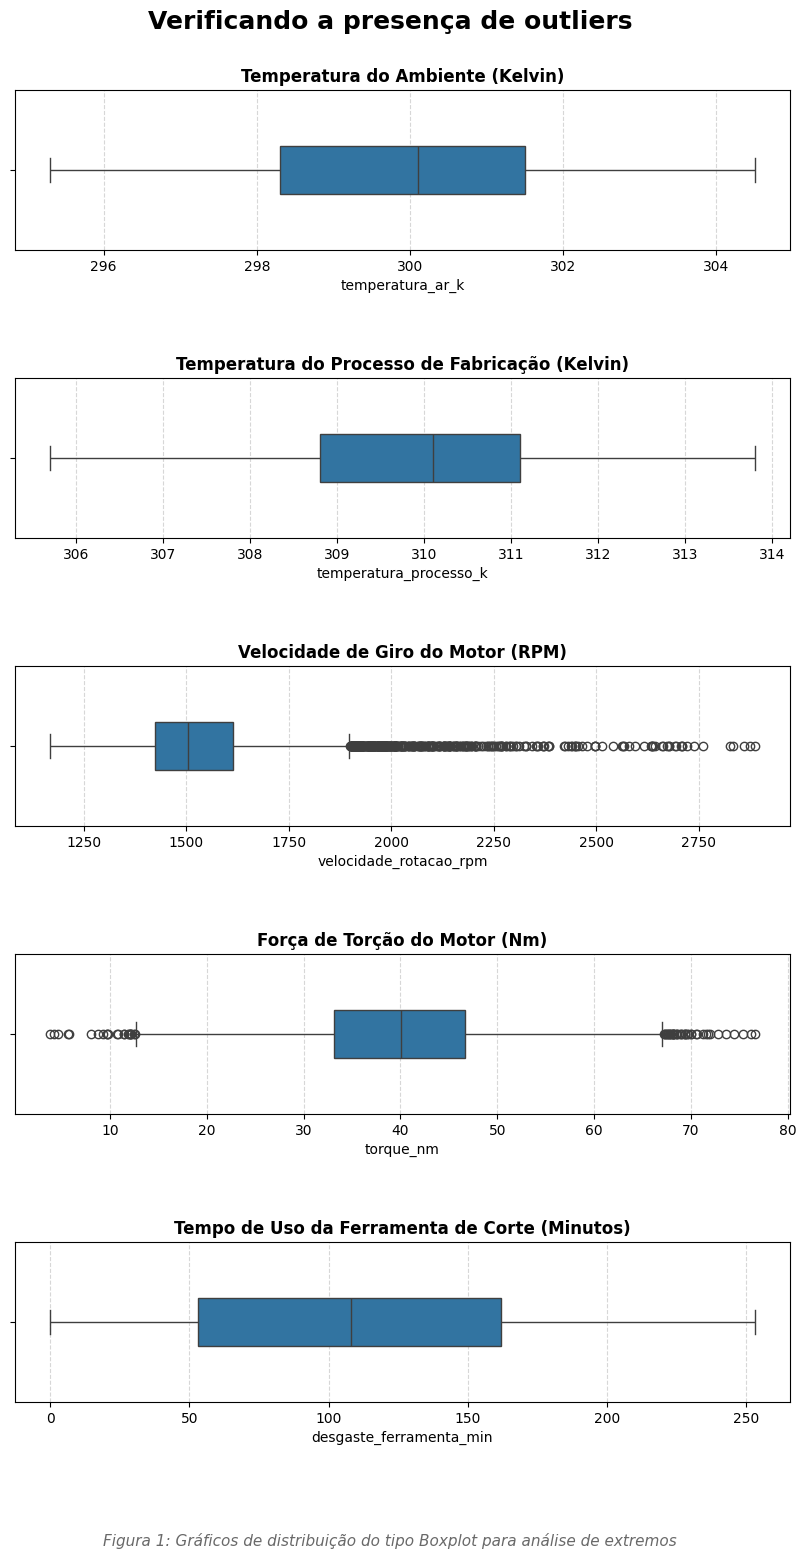

In [7]:
# Definindo variáveis a serem verificadas
colunas = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min"
]

# Definindo os títulos de cada boxplot
titulos_personalizados = {
    "temperatura_ar_k": "Temperatura do Ambiente (Kelvin)",
    "temperatura_processo_k": "Temperatura do Processo de Fabricação (Kelvin)",
    "velocidade_rotacao_rpm": "Velocidade de Giro do Motor (RPM)",
    "torque_nm": "Força de Torção do Motor (Nm)",
    "desgaste_ferramenta_min": "Tempo de Uso da Ferramenta de Corte (Minutos)"
}
# Configuração dos subplots
fig, axes = plt.subplots(5, 1, figsize=(10, 16))

# Definição do título geral
fig.suptitle("Verificando a presença de outliers", fontsize=18, fontweight='bold')

# Adicionando rodapé de identificação na base da figura
fig.text(x=0.5, y=0.02, 
         s="Figura 1: Gráficos de distribuição do tipo Boxplot para análise de extremos", 
         fontsize=11, fontstyle='italic', color='dimgray', ha='center')

# Plotando os gráficos
for ax, coluna in zip(axes.flatten(), colunas):
    sns.boxplot(
        x=df_bruto[coluna],
        ax=ax,
        width=0.3
    )

    # Título intuitivo no topo de cada gráfico
    titulo_atual = titulos_personalizados[coluna]
    ax.set_title(titulo_atual, fontsize=12, fontweight='semibold', color="black") 
    
    # Eixo X exibe o nome original da coluna
    ax.set_xlabel(coluna, fontsize=10)
    ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.subplots_adjust(hspace=0.8, top=0.93) 

# Salvando os gráficosos na pasta outputs
caminho_arquivo = os.path.join("outputs", "figura1.png")

plt.savefig(
    caminho_arquivo, 
    dpi=300,             # Alta resolução
    bbox_inches='tight'  # Garante que nenhum pedaço do rodapé ou título seja cortado ao salvar
)

plt.show()


In [8]:
# Verificando a quantidade de outliers presentes nas colunas `velocidade_rotacao_rpm`e `torque_nm` e impacto na média dos valores.


colunas = ['velocidade_rotacao_rpm','torque_nm']
TOTAL_REGISTROS = 10000

for col in colunas:
    # Calcula os quartis e o IQR
    Q1 = df_bruto[col].quantile(0.25)
    Q3 = df_bruto[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define os limites de Tukey
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Filtra e conta os outliers
    outliers = df_bruto[(df_bruto[col] < limite_inferior) | (df_bruto[col] > limite_superior)]
    total_outliers = len(outliers)
    
    # Calcula a proporção em relação ao total de 10.000
    proporcao = (total_outliers / TOTAL_REGISTROS) * 100
    
    # Exibe os resultados
    print(f"Coluna '{col}':")
    print(f"  - Limite Inferior: {limite_inferior:.2f} | Limite Superior: {limite_superior:.2f}")
    print(f"  - Total de outliers: {total_outliers}")
    print(f"  - Proporção de outliers: {proporcao:.2f}% do total (10k)")
    print("-" * 50)

Coluna 'velocidade_rotacao_rpm':
  - Limite Inferior: 1138.00 | Limite Superior: 1898.00
  - Total de outliers: 398
  - Proporção de outliers: 3.98% do total (10k)
--------------------------------------------------
Coluna 'torque_nm':
  - Limite Inferior: 12.70 | Limite Superior: 67.10
  - Total de outliers: 63
  - Proporção de outliers: 0.63% do total (10k)
--------------------------------------------------


Verificando a proporção de falhas(`falha_maquina`) por categoria de instrumentos (`tipo`)

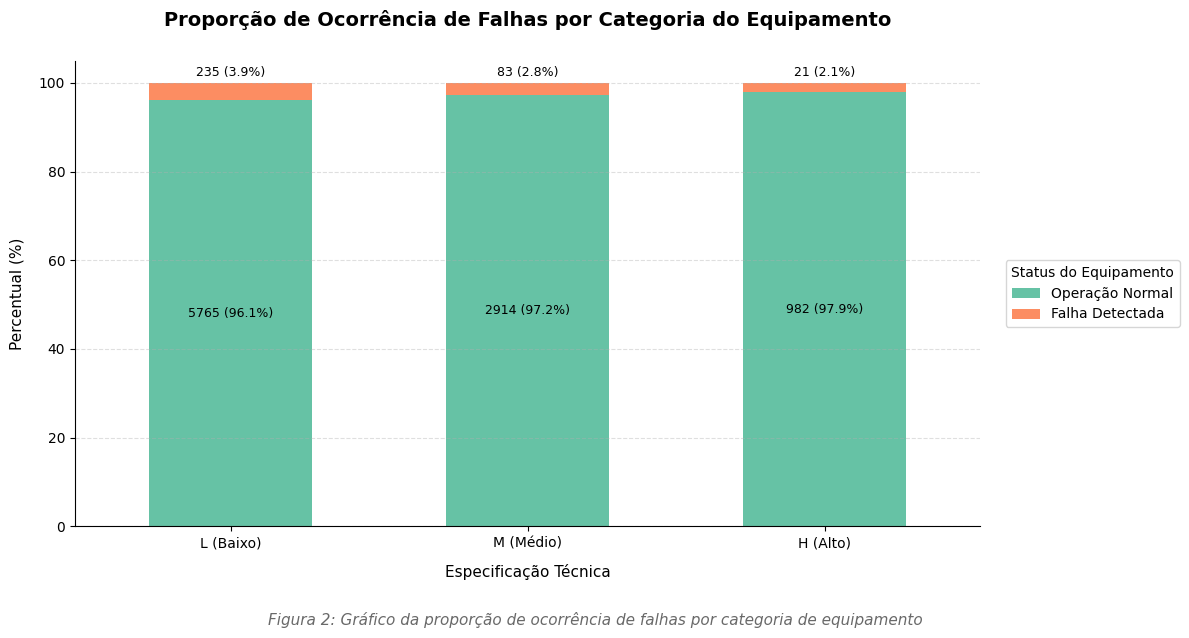

In [9]:
# Calculando os valores absolutos e percentuais
tabela_absoluta = pd.crosstab(df_bruto["tipo"], df_bruto["falha_maquina"]).reindex(["L", "M", "H"])
tabela_proporcao = pd.crosstab(df_bruto["tipo"], df_bruto["falha_maquina"], normalize="index") * 100
tabela_proporcao = tabela_proporcao.reindex(["L", "M", "H"])

# Configurando a janela do gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Plotando o gráfico
tabela_proporcao.plot(
    kind="bar", 
    stacked=True, 
    ax=ax, 
    color=sns.color_palette("Set2")[:2],
    width=0.55
)

# Adicionando os rótulos
for i, container in enumerate(ax.containers):
    labels_customizados = []
    
    for idx, categoria in enumerate(["L", "M", "H"]):
        abs_val = tabela_absoluta.loc[categoria, i]
        pct_val = tabela_proporcao.loc[categoria, i]
        labels_customizados.append(f"{abs_val} ({pct_val:.1f}%)")
    
    # Se for a barra de falhas (i == 1), usamos uma estratégia para não esmagar o texto
    if i == 1:
        # Coloca o texto logo ACIMA do topo da barra (edge) em vez de centralizar
        ax.bar_label(container, labels=labels_customizados, label_type="edge", padding=3, fontsize=9)
    else:
        # Mantém centralizado no bloco grande verde
        ax.bar_label(container, labels=labels_customizados, label_type="center", fontsize=9)

# Títulos e rótulos
ax.set_title("Proporção de Ocorrência de Falhas por Categoria do Equipamento", fontsize=14, fontweight='bold', pad=25)
ax.set_ylabel("Percentual (%)", fontsize=11, labelpad=10)
ax.set_xlabel("Especificação Técnica", fontsize=11, labelpad=10)

# Adicionando rodapé de identificação na base da figura
fig.text(x=0.5, y=-0.05, 
         s="Figura 2: Gráfico da proporção de ocorrência de falhas por categoria de equipamento", 
         fontsize=11, fontstyle='italic', color='dimgray', ha='center')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["L (Baixo)", "M (Médio)", "H (Alto)"], rotation=0)

# Limita o eixo Y em 105 para que o texto acima da última barra não seja cortado
ax.set_ylim(0, 105)

# Legenda externa centralizada verticalmente
ax.legend(
    title="Status do Equipamento", 
    labels=["Operação Normal", "Falha Detectada"], 
    loc="center left", 
    bbox_to_anchor=(1.02, 0.5)
)

ax.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()

# Salvando os gráficosos na pasta outputs
caminho_arquivo = os.path.join("outputs", "figura2.png")

plt.savefig(
    caminho_arquivo, 
    dpi=300,             # Alta resolução
    bbox_inches='tight'  # Garante que nenhum pedaço do rodapé ou título seja cortado ao salvar
)

plt.show()

Verificando correlação preliminar entre as variáveis

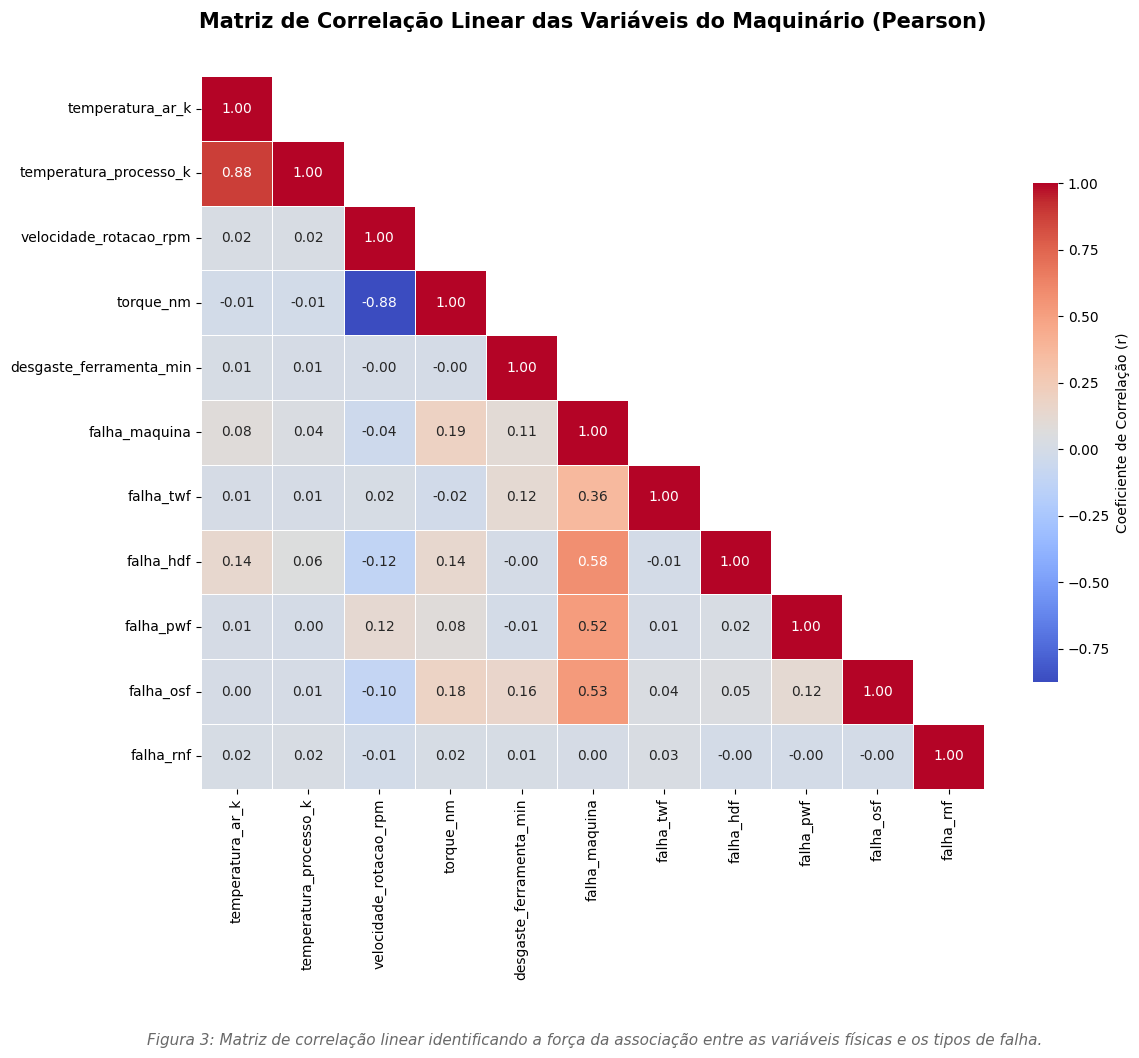

In [10]:
# Filtrando apenas as colunas numéricas relevantes (removendo o id numérico 'udi')
df_numerico = df_bruto.select_dtypes(include=[np.number])
if 'udi' in df_numerico.columns:
    df_numerico = df_numerico.drop(columns=['udi'])

# Calculando a matriz de correlação correta
matriz_correlacao = df_numerico.corr()

# Criando a máscara para o triângulo superior (mantendo a diagonal principal se k=1)
mascara = np.triu(np.ones_like(matriz_correlacao, dtype=bool), k=1)

# Configurando a figura
fig = plt.figure(figsize=(12, 10))

# Plotando o Heatmap
sns.heatmap(
    matriz_correlacao, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=.5,
    mask=mascara,
    cbar_kws={"shrink": 0.7, "label": "Coeficiente de Correlação (r)"}
)

# Título principal no topo
plt.title(
    'Matriz de Correlação Linear das Variáveis do Maquinário (Pearson)', 
    fontsize=15, 
    fontweight='bold', 
    pad=35
)

# Ajuste de layout para as variáveis do eixo X não cortarem
plt.tight_layout()

# Rodapé corrigido com base nas informações REAIS do seu gráfico
fig.text(x=0.5, y=-0.05, 
         s="Figura 3: Matriz de correlação linear identificando a força da associação entre as variáveis físicas e os tipos de falha.", 
         fontsize=11, fontstyle='italic', color='dimgray', ha='center')

# Salvando os gráficosos na pasta outputs
caminho_arquivo = os.path.join("outputs", "figura3.png")

plt.savefig(
    caminho_arquivo, 
    dpi=300,             # Alta resolução
    bbox_inches='tight'  # Garante que nenhum pedaço do rodapé ou título seja cortado ao salvar
)

plt.show()



### Conclusões Iniciais do Dataset e Direcionamento de Modelagem

1. **Dimensões do Conjunto de Dados:** O conjunto de dados apresenta 10.000 registros e 14 colunas, fornecendo uma volumetria estatisticamente robusta para o treinamento de modelos de aprendizado supervisionado.

2. **Variáveis Únicas e Integridade:** As variáveis `udi` e `id_produto` possuem cardinalidade máxima (10.000 valores únicos). Isso confirma que cada linha descreve um evento único de acompanhamento do maquinário. A tipagem automática das variáveis realizada pelo Pandas está adequada à natureza de cada coluna.

3. **Análise de Valores Ausentes:** As colunas `temperatura_ar_k`, `temperatura_processo_k`, `velocidade_rotacao_rpm` e `torque_nm` apresentam exatamente 500 valores nulos cada (representando 5,0% de ausência por coluna). A verificação lógica comprovou que as ausências ocorrem **exatamente nas mesmas linhas** e para os mesmos produtos (`id_produto`). Como os nulos estão perfeitamente alinhados, a remoção em massa descartaria 5% da base de forma desnecessária.
   * **Direcionamento de Modelagem:** Optaremos pela imputação de dados. O método de preenchimento dessas lacunas na **Fase 2** será guiado individualmente pela presença de outliers em cada distribuição.

4. **Análise de Outliers e Dinâmica de Operação:** A avaliação visual do Boxplot (Figura 1) e o cálculo estatístico dos limites de Tukey revelaram comportamentos distintos entre as variáveis explicativas:
   * As temperaturas (`temperatura_ar_k` e `temperatura_processo_k`) e o tempo de uso (`desgaste_ferramenta_min`) não possuem outliers severos, apresentando desvios padrões controlados.
   * As variáveis mecânicas sofrem com anomalias de operação: `velocidade_rotacao_rpm` apresenta 398 outliers (3,98% dos dados, com máxima de 2.886 RPM) e `torque_nm` apresenta 63 outliers (0,63% dos dados).
   * **Direcionamento de Modelagem:** Pela presença marcante de outliers nessas colunas, a **Mediana** será preferida em vez da Média para a imputação de dados ausentes, evitando distorções estatísticas causadas por esses valores extremos.

5. **Severo Desbalanceamento da Variável Alvo:** A média aritmética da coluna binária `falha_maquina` é de **0,0339**, o que significa que apenas **3,39%** das observações registram falhas de maquinário.
   * **Direcionamento de Modelagem:** O dataset é fortemente desbalanceado (Figura 2). Algoritmos de Machine Learning tendem a ignorar a classe minoritária se treinados nessa configuração. Isso justifica e direciona a aplicação obrigatória de técnicas de reamostragem (como o SMOTE) na **Fase 4**, aplicada estritamente nos dados de treino para evitar vazamento de dados (*Data Leakage*).

6. **Correlação Linear e Multicolinearidade:** A matriz de Pearson (Figura 3) revelou duas associações lineares críticas: uma forte correlação positiva entre as temperaturas do ar e do processo ($r = 0,88$) e uma forte correlação negativa entre velocidade de rotação e torque ($r = -0,88$).
   * **Direcionamento de Modelagem:** A alta multicolinearidade distorce algoritmos baseados em cálculo de distância geométrica, como o **KNN**, pois variáveis altamente correlacionadas acabam tendo seu "peso" computado em dobro na métrica de distância. Por isso, a etapa de escalonamento via `StandardScaler` na **Fase 5** será fundamental para mitigar assimetrias no KNN. Em contrapartida, modelos baseados em **Árvores de Decisão** avaliam atributos de forma isolada a cada quebra (*split*), tornando-se naturalmente imunes aos efeitos da escala e da colinearidade.

<br>

## Fase 2: Limpeza e Tratamento de Dados (Data Prep)

<br>

Tratamento de valores nulos

As colunas `temperatura_ar_k`, `temperatura_processo_k`, `velocidade_rotacao_rpm` e `torque_nm` apresentam 500 valores nulos cada.

In [11]:
# Criando uma cópia do dataframe para realização das alterações. Servirá como checkpoint durante a fase2

df = df_bruto.copy()
# df.head(5)

In [12]:
# Diante da ausência de outliers e do baixo desvio padrão nas colunas `temperatura_ar_k` e `temperatura_processo_k`, a distribuição dos dados mostra-se homogênea. 
# Esses fatores justificam tecnicamente a escolha da média para a imputação dos valores nulos nessas colunas.


# Calculando a média

temp_ar_media = df['temperatura_ar_k'].mean().round(1)
# print(temp_ar_media)
temp_processo_media = df['temperatura_processo_k'].mean().round(1)
# print(temp_processo_media)

# Atribuindo aos nulos

df['temperatura_ar_k'] = df['temperatura_ar_k'].fillna(temp_ar_media)
df['temperatura_processo_k'] = df['temperatura_processo_k'].fillna(temp_processo_media)


In [13]:
# As colunas `velocidade_rotacao_rpm` e `torque_nm` apresentam outliers. 
# Embora a proximidade entre médias e medianas em ambas as variáveis permita o uso de qualquer uma delas, 
# optou-se pela mediana por ser uma medida central robusta a valores extremos

# Calculando a mediana

veloc_rotacao_mediana = df['velocidade_rotacao_rpm'].median().round(1)
#print(veloc_rotacao_mediana)
torque_mediana = df['torque_nm'].median().round(1)
#print(torque_mediana)

# Atribuindo aos nulos

df['velocidade_rotacao_rpm'] = df['velocidade_rotacao_rpm'].fillna(veloc_rotacao_mediana)
df['torque_nm'] = df['torque_nm'].fillna(torque_mediana)

In [14]:
def verificar_tratativa_nulos(df_original, df_tratado, colunas, coluna_id):
    """
    Compara dois DataFrames (Antes e Depois) para validar a remoção de valores nulos,
    gerando um relatório detalhado, exibindo uma amostra e retornando o DataFrame isolado.
    """
    print("=" * 65)
    print("       RELATÓRIO UNIFICADO: TRATATIVA DE VALORES NULOS")
    print("=" * 65 + "\n")

    colunas_com_erro = {}
    resumo_dados = []
    todos_ids_afetados = set()

    for col in colunas:
        # Captura os IDs que eram nulos no DataFrame original
        ids_nulos_antes = df_original.loc[df_original[col].isna(), coluna_id].unique()
        todos_ids_afetados.update(ids_nulos_antes)
        
        # Verifica o estado atual no DataFrame tratado
        df_nulos_atual = df_tratado[df_tratado[col].isna()]
        nulos_antes = len(ids_nulos_antes)
        nulos_depois = len(df_nulos_atual)
        
        # Alimenta os dados do resumo
        resumo_dados.append({
            'Coluna': col,
            'Nulos Antes': nulos_antes,
            'Nulos Depois': nulos_depois,
            'Diferença (Tratados)': nulos_antes - nulos_depois
        })
        
        # Exibe o status rápido na tela
        if df_nulos_atual.empty:
            print(f"✅ {col:<25} | Tratativa com SUCESSO! (Corrigidos: {nulos_antes} IDs)")
        else:
            print(f"❌ {col:<25} | ATENÇÃO: Ainda restam {nulos_depois} itens nulos!")
            colunas_com_erro[col] = df_nulos_atual

    print("\n" + "-" * 65 + "\n")

    # Exibição do Quadro Comparativo
    df_comparativo = pd.DataFrame(resumo_dados).set_index('Coluna')
    print("QUADRO COMPARATIVO GERAL:")
    display(df_comparativo)

    print("\n" + "-" * 65 + "\n")

    # Criação do DataFrame com os registros que sofreram alteração
    df_registros_tratados = df_tratado[df_tratado[coluna_id].isin(todos_ids_afetados)]
    print(f"Total de registros únicos ({coluna_id}) que passaram por tratativa: {len(todos_ids_afetados)}")
    print("Amostra dos dados tratados (primeiras 5 linhas):")
    display(df_registros_tratados.head(5))  # <--- Linha reinserida aqui!
    
    # Se houver erros, detalha no final
    if colunas_com_erro:
        print("\n" + "!" * 65)
        print("DETALHAMENTO DE FALHAS CRÍTICAS (Nulos persistentes):")
        for col, df_erro in colunas_com_erro.items():
            print(f"\nLinhas que falharam na coluna [{col}]:")
            display(df_erro)
            
    # Retorna o DataFrame contendo apenas os dados corrigidos
    return df_registros_tratados


In [15]:
# Lista de colunas que foram tratadas

colunas_analise = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm']

# Chamada da função
df_produtos_tratados = verificar_tratativa_nulos(
    df_original=df_bruto, 
    df_tratado=df, 
    colunas=colunas_analise, 
    coluna_id='id_produto'
)


       RELATÓRIO UNIFICADO: TRATATIVA DE VALORES NULOS

✅ temperatura_ar_k          | Tratativa com SUCESSO! (Corrigidos: 500 IDs)
✅ temperatura_processo_k    | Tratativa com SUCESSO! (Corrigidos: 500 IDs)
✅ velocidade_rotacao_rpm    | Tratativa com SUCESSO! (Corrigidos: 500 IDs)
✅ torque_nm                 | Tratativa com SUCESSO! (Corrigidos: 500 IDs)

-----------------------------------------------------------------

QUADRO COMPARATIVO GERAL:


,Nulos Antes,Nulos Depois,Diferença (Tratados)
Coluna,,,
temperatura_ar_k,500,0,500
temperatura_processo_k,500,0,500
velocidade_rotacao_rpm,500,0,500
torque_nm,500,0,500



-----------------------------------------------------------------

Total de registros únicos (id_produto) que passaram por tratativa: 500
Amostra dos dados tratados (primeiras 5 linhas):


,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
3,4,L47183,L,300.0,310.0,1504.0,40.1,7,0,0,0,0,0,0
14,15,L47194,L,300.0,310.0,1504.0,40.1,40,0,0,0,0,0,0
29,30,L47209,L,300.0,310.0,1504.0,40.1,84,0,0,0,0,0,0
31,32,L47211,L,300.0,310.0,1504.0,40.1,89,0,0,0,0,0,0
33,34,L47213,L,300.0,310.0,1504.0,40.1,93,0,0,0,0,0,0


Criação de um dataset com as colunas preditoras e a coluna alvo:

As colunas identificadoras `udi`, `id_produto` e as que detalham tipos específicos de falhas (`falha_twf`, `falha_hdf`, `falha_pwf`, `falha_osf` e `falha_rnf`) serão removidas por não possuírem poder preditivo geral. Manteremos apenas os atributos operacionais (variáveis preditoras) e a coluna `falha_maquina`, que atuará como a nossa variável alvo na modelagem.

In [16]:
# Criação de dataset com as variáveis preditoras (features) e coluna alvo (target)

recursos_preditores_alvo = [
    'tipo', 
    'temperatura_ar_k', 
    'temperatura_processo_k', 
    'velocidade_rotacao_rpm', 
    'torque_nm', 
    'desgaste_ferramenta_min',
    'falha_maquina' # Variável alvo
]


df = df[recursos_preditores_alvo]

df.head(6)

,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina
0,M,298.1,308.6,1551.0,42.8,0,0
1,L,298.2,308.7,1408.0,46.3,3,0
2,L,298.1,308.5,1498.0,49.4,5,0
3,L,300.0,310.0,1504.0,40.1,7,0
4,L,298.2,308.7,1408.0,40.0,9,0
5,M,298.1,308.6,1425.0,41.9,11,0


### Resumo: Limpeza e Tratamento de Dados (Data Prep)

 **1. Tratamento de Dados Ausentes (Imputação)**
As colunas `temperatura_ar_k`, `temperatura_processo_k`, `velocidade_rotacao_rpm` e `torque_nm` apresentavam originalmente 500 valores nulos cada (5,0% do dataset). O tratamento foi conduzido de forma personalizada, respeitando a distribuição de cada variável:

* **Imputação pela Média:** Aplicada às variáveis `temperatura_ar_k` e `temperatura_processo_k`. Justifica-se pela ausência de outliers proeminentes e baixo desvio padrão, caracterizando distribuições homogêneas onde a média representa fielmente o centro dos dados.
* **Imputação pela Mediana:** Aplicada às variáveis `velocidade_rotacao_rpm` e `torque_nm`. Justifica-se pela presença confirmada de outliers (3,98% e 0,63% de dados extremos, respectivamente). A mediana, por ser uma medida de tendência central não paramétrica, blinda o preenchimento contra distorções causadas por esses valores discrepantes.

**2. Engenharia de Seleção de Recursos (Feature Selection)**
Para estruturar o dataset final, realizamos uma filtragem criteriosa dos atributos:
* **Remoção de Identificadores:** As colunas `udi` e `id_produto` foram descartadas por apresentarem cardinalidade máxima (valores únicos), agindo apenas como indexadores sem poder preditivo para os algoritmos.
* **Remoção de Vazamentos (*Data Leakage*):** As colunas de falhas específicas (`falha_twf`, `falha_hdf`, `falha_pwf`, `falha_osf` e `falha_rnf`) foram excluídas. Mantê-las causaria vazamento de informação, pois elas revelam diretamente a ocorrência da falha que a variável alvo (`falha_maquina`) tenta prever.
* **Dataset Finalizado:** Mantivemos apenas as variáveis operacionais preditoras (`tipo`, `temperatura_ar_k`, `temperatura_processo_k`, `velocidade_rotacao_rpm`, `torque_nm` e `desgaste_ferramenta_min`) correlacionadas ao nosso alvo (`falha_maquina`).